In [2]:
# 1. Import Libraries

In [3]:
# Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import shap

from lime.lime_tabular import LimeTabularExplainer

In [4]:
# 2. Load Dataset

In [5]:
# Load Dataset


df = pd.read_csv("CIC_IDS2017_balanced2.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (11400, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,206,2,2,68,132,34,34,34.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,443,676974,9,6,1697,1221,1349,0,188.555556,441.134931,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,443,63161627,7,0,0,0,0,0,0.000000,0.000000,...,40,7009617.0,0.0,7009617,7009617,18700000.0,12300000.0,32100000,8023974,Benign
3,53,79283,1,1,56,137,56,56,56.000000,0.000000,...,40,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,443,294065,19,29,871,39643,389,0,45.842105,105.687308,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [6]:
# 3. Dataset Validation

In [7]:
# Clean Column Names


df.columns = df.columns.str.strip()

print("Target Column:")
print(df.columns[-1])

Target Column:
Label


In [8]:
# Dataset Validation


print("Dataset Shape :", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["Label"].value_counts())

Dataset Shape : (11400, 79)

Missing Values:
0

Class Distribution:
Label
Benign        1900
Bot           1900
BruteForce    1900
DoS           1900
PortScan      1900
WebAttack     1900
Name: count, dtype: int64


In [9]:
# 4. Data Preparation

In [10]:
# Feature and Target Separation


X = df.drop("Label", axis=1)
y = df["Label"]

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (11400, 78)
Target Shape : (11400,)


In [11]:
# Label Encoding


label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

label_mapping = {
    label: int(code)
    for label, code in zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
}

print("Label Mapping:")
print(label_mapping)

Label Mapping:
{'Benign': 0, 'Bot': 1, 'BruteForce': 2, 'DoS': 3, 'PortScan': 4, 'WebAttack': 5}


In [12]:
# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (9120, 78)
Test Shape : (2280, 78)


In [13]:
# Class Distribution Check


print("Training Set Distribution")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting Set Distribution")
print(pd.Series(y_test).value_counts().sort_index())

Training Set Distribution
0    1520
1    1520
2    1520
3    1520
4    1520
5    1520
Name: count, dtype: int64

Testing Set Distribution
0    380
1    380
2    380
3    380
4    380
5    380
Name: count, dtype: int64


In [14]:
# Feature Scaling


scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape :", X_test_scaled.shape)

Scaled Training Shape: (9120, 78)
Scaled Testing Shape : (2280, 78)


In [15]:
# 5. Model Development

## 5.1 Random Forest

In [16]:
# Random Forest Training


rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Training Completed")

Random Forest Training Completed


In [17]:
# Random Forest Prediction


y_pred_rf = rf_model.predict(X_test)

print("Random Forest Prediction Completed")

Random Forest Prediction Completed


In [18]:
# Random Forest Evaluation


rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

Accuracy  : 0.9947
Precision : 0.9948
Recall    : 0.9947
F1-Score  : 0.9947


In [19]:
### Classification Report

In [20]:
# Random Forest Classification Report


class_names = label_encoder.classes_

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99       380
         Bot       0.99      1.00      1.00       380
  BruteForce       1.00      1.00      1.00       380
         DoS       0.99      1.00      0.99       380
    PortScan       1.00      1.00      1.00       380
   WebAttack       0.99      0.99      0.99       380

    accuracy                           0.99      2280
   macro avg       0.99      0.99      0.99      2280
weighted avg       0.99      0.99      0.99      2280



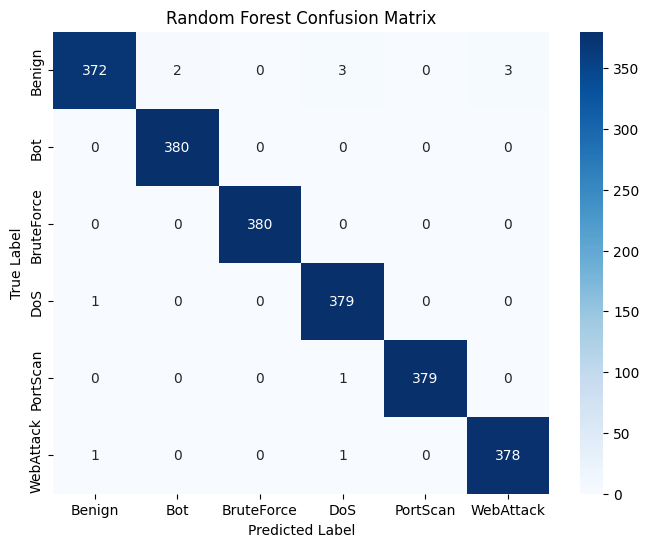

In [21]:
# Random Forest Confusion Matrix


cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [22]:
## 5.2 XGBoost

In [23]:
# XGBoost Training


xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost Training Completed")

XGBoost Training Completed


In [24]:
# XGBoost Prediction


y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Prediction Completed")

XGBoost Prediction Completed


In [25]:
# XGBoost Evaluation


xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1-Score  : {xgb_f1:.4f}")

Accuracy  : 0.9965
Precision : 0.9965
Recall    : 0.9965
F1-Score  : 0.9965


In [26]:
### Classification Report

In [27]:
# XGBoost Classification Report


print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99       380
         Bot       0.99      1.00      0.99       380
  BruteForce       1.00      1.00      1.00       380
         DoS       0.99      1.00      0.99       380
    PortScan       1.00      1.00      1.00       380
   WebAttack       1.00      1.00      1.00       380

    accuracy                           1.00      2280
   macro avg       1.00      1.00      1.00      2280
weighted avg       1.00      1.00      1.00      2280



In [28]:
### Confusion Matrix

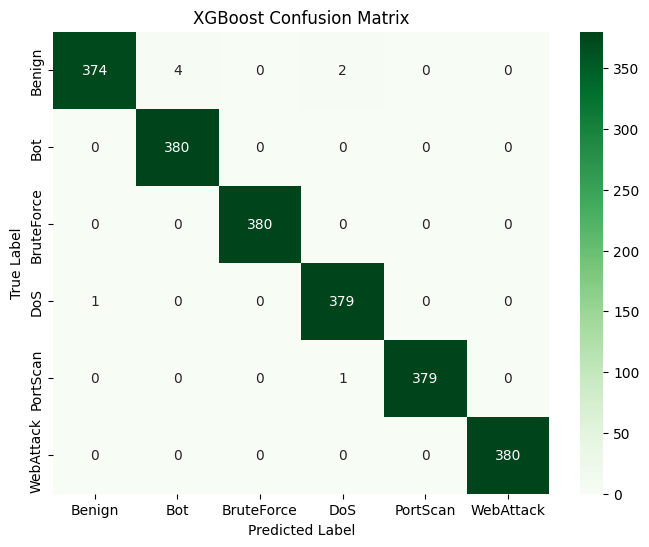

In [29]:
# XGBoost Confusion Matrix


cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [30]:
## 5.3 Multi Layer Perceptron (MLP)

In [31]:
# MLP Training


mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp_model.fit(
    X_train_scaled,
    y_train
)

print("MLP Training Completed")

MLP Training Completed


In [32]:
# MLP Prediction


y_pred_mlp = mlp_model.predict(
    X_test_scaled
)

print("MLP Prediction Completed")

MLP Prediction Completed


In [33]:
# MLP Evaluation


mlp_accuracy = accuracy_score(
    y_test,
    y_pred_mlp
)

mlp_precision = precision_score(
    y_test,
    y_pred_mlp,
    average="weighted"
)

mlp_recall = recall_score(
    y_test,
    y_pred_mlp,
    average="weighted"
)

mlp_f1 = f1_score(
    y_test,
    y_pred_mlp,
    average="weighted"
)

print(f"Accuracy  : {mlp_accuracy:.4f}")
print(f"Precision : {mlp_precision:.4f}")
print(f"Recall    : {mlp_recall:.4f}")
print(f"F1-Score  : {mlp_f1:.4f}")

Accuracy  : 0.9776
Precision : 0.9782
Recall    : 0.9776
F1-Score  : 0.9775


In [34]:
### Classification Report

In [35]:
# MLP Classification Report


print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      Benign       1.00      0.93      0.96       380
         Bot       0.98      1.00      0.99       380
  BruteForce       0.95      0.99      0.97       380
         DoS       0.96      1.00      0.98       380
    PortScan       1.00      1.00      1.00       380
   WebAttack       0.98      0.95      0.96       380

    accuracy                           0.98      2280
   macro avg       0.98      0.98      0.98      2280
weighted avg       0.98      0.98      0.98      2280



In [36]:
### Confusion Matrix

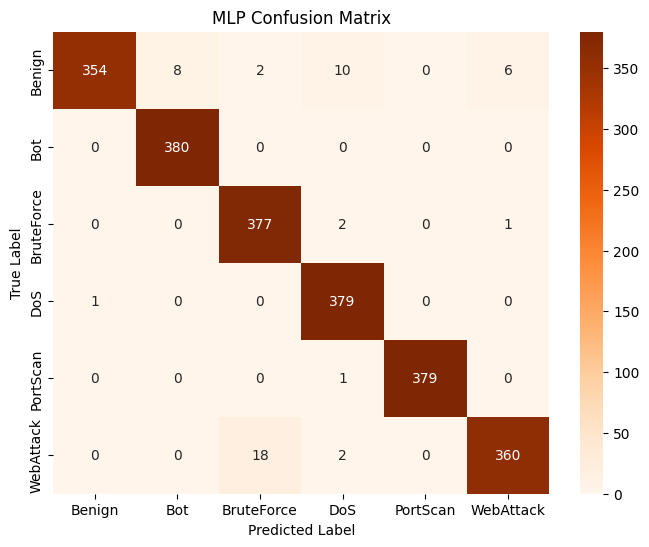

In [37]:
# MLP Confusion Matrix


cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [38]:
# 6. Performance Evaluation

In [39]:
# Performance Evaluation


performance_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "MLP"
    ],
    "Accuracy": [
        rf_accuracy,
        xgb_accuracy,
        mlp_accuracy
    ],
    "Precision": [
        rf_precision,
        xgb_precision,
        mlp_precision
    ],
    "Recall": [
        rf_recall,
        xgb_recall,
        mlp_recall
    ],
    "F1": [
        rf_f1,
        xgb_f1,
        mlp_f1
    ]
})

performance_df = performance_df.round(4)
performance_df

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.9947,0.9948,0.9947,0.9947
1,XGBoost,0.9965,0.9965,0.9965,0.9965
2,MLP,0.9776,0.9782,0.9776,0.9775


In [40]:
### Best Model Selection

In [41]:
# Best Model Selection


best_model_name = performance_df.loc[
    performance_df["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [42]:
#7. Global Explainability Analysis using SHAP

#Section ini menganalisis kontribusi fitur menggunakan SHAP untuk memahami proses pengambilan keputusan dari setiap model machine learning.

In [43]:
## 7.1 Random Forest SHAP Analysis

In [44]:
# Random Forest SHAP Explainer


explainer_rf = shap.TreeExplainer(
    rf_model
)

shap_values_rf = explainer_rf(
    X_test
)

print("Random Forest SHAP Completed")

Random Forest SHAP Completed


In [45]:
# Random Forest Mean SHAP Values


rf_shap_mean = np.abs(
    shap_values_rf.values
).mean(axis=(0, 2))

rf_shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP": rf_shap_mean
})

rf_shap_importance = rf_shap_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

rf_shap_importance.head(10)

,Feature,Mean_SHAP
0,Destination Port,0.032511
11,Bwd Packet Length Min,0.030731
67,Init_Win_bytes_backward,0.018677
52,Average Packet Size,0.012781
66,Init_Win_bytes_forward,0.010509
15,Flow Packets/s,0.010006
4,Total Length of Fwd Packets,0.009741
37,Bwd Packets/s,0.008856
69,min_seg_size_forward,0.008589
16,Flow IAT Mean,0.008102


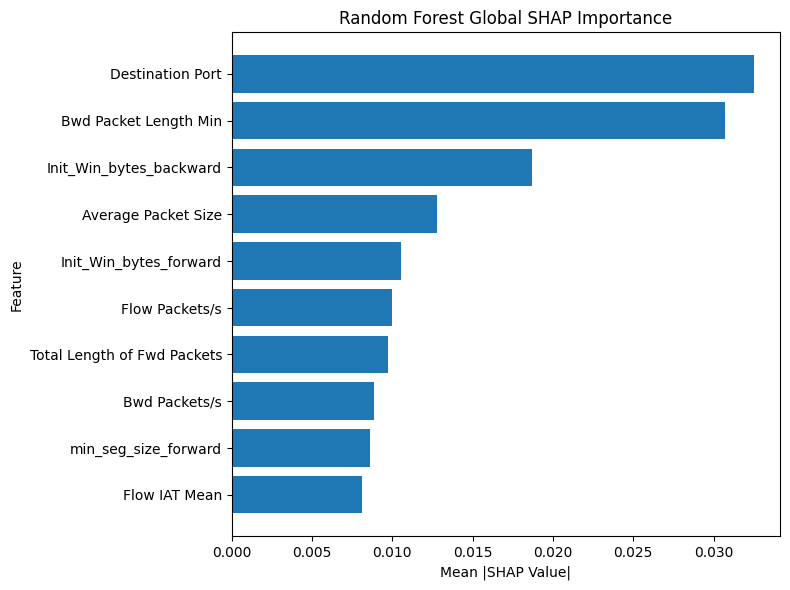

In [46]:
# Random Forest Global SHAP Plot


top10_rf = rf_shap_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10_rf["Feature"][::-1],
    top10_rf["Mean_SHAP"][::-1]
)

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.title("Random Forest Global SHAP Importance")

plt.tight_layout()
plt.show()

In [47]:
## 7.2 XGBoost SHAP Analysis

In [48]:
# XGBoost SHAP Explainer


explainer_xgb = shap.TreeExplainer(
    xgb_model
)

shap_values_xgb = explainer_xgb(
    X_test
)

print("XGBoost SHAP Completed")

XGBoost SHAP Completed


In [49]:
# XGBoost Mean SHAP Values


xgb_shap_mean = np.abs(
    shap_values_xgb.values
).mean(axis=(0, 2))

xgb_shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP": xgb_shap_mean
})

xgb_shap_importance = xgb_shap_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

xgb_shap_importance.head(10)

,Feature,Mean_SHAP
0,Destination Port,1.853921
67,Init_Win_bytes_backward,0.566692
37,Bwd Packets/s,0.402260
66,Init_Win_bytes_forward,0.394701
40,Packet Length Mean,0.360132
69,min_seg_size_forward,0.269145
24,Fwd IAT Min,0.217613
46,PSH Flag Count,0.198364
14,Flow Bytes/s,0.189196
19,Flow IAT Min,0.180552


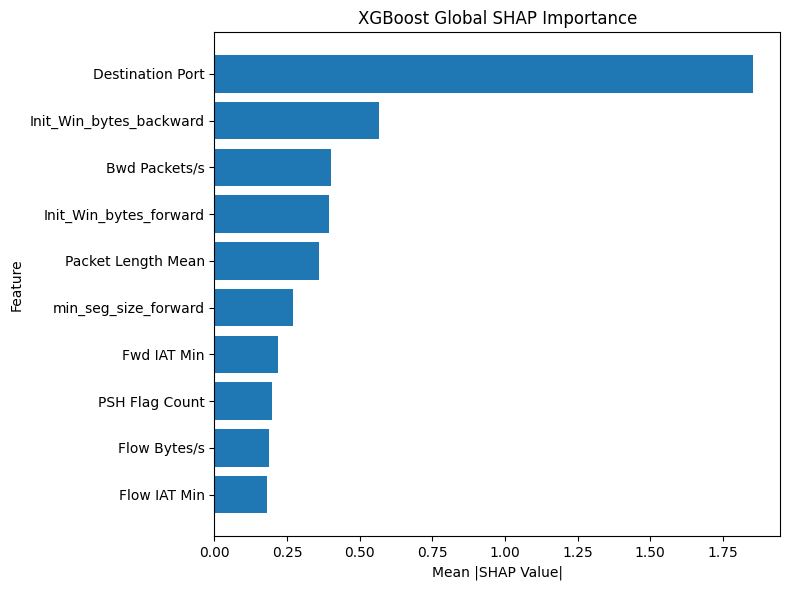

In [50]:
# XGBoost Global SHAP Plot


top10_xgb = xgb_shap_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10_xgb["Feature"][::-1],
    top10_xgb["Mean_SHAP"][::-1]
)

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.title("XGBoost Global SHAP Importance")

plt.tight_layout()
plt.show()

In [51]:
## 7.3 MLP SHAP Analysis

In [52]:
# Background Data for Kernel SHAP


background = shap.sample(
    X_train_scaled,
    100,
    random_state=42
)

X_mlp_sample = shap.sample(
    X_test_scaled,
    200,
    random_state=42
)

In [53]:
# MLP Kernel SHAP Explainer


explainer_mlp = shap.KernelExplainer(
    mlp_model.predict_proba,
    background
)

print("MLP SHAP Explainer Created")

MLP SHAP Explainer Created


In [54]:
# MLP SHAP Values


shap_values_mlp = explainer_mlp.shap_values(
    X_mlp_sample
)

print("MLP SHAP Calculation Completed")

  0%|          | 0/200 [00:00<?, ?it/s]

MLP SHAP Calculation Completed


In [55]:
# MLP Mean SHAP Values

mlp_shap_mean = np.abs(
    shap_values_mlp
).mean(axis=(0, 2))

mlp_shap_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Mean_SHAP": mlp_shap_mean
})

mlp_shap_importance = mlp_shap_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

mlp_shap_importance.head(10)

,Feature,Mean_SHAP
69,min_seg_size_forward,0.050406
0,Destination Port,0.034183
66,Init_Win_bytes_forward,0.028765
67,Init_Win_bytes_backward,0.027875
47,ACK Flag Count,0.020289
46,PSH Flag Count,0.019478
51,Down/Up Ratio,0.016686
38,Min Packet Length,0.015145
37,Bwd Packets/s,0.012712
48,URG Flag Count,0.012280


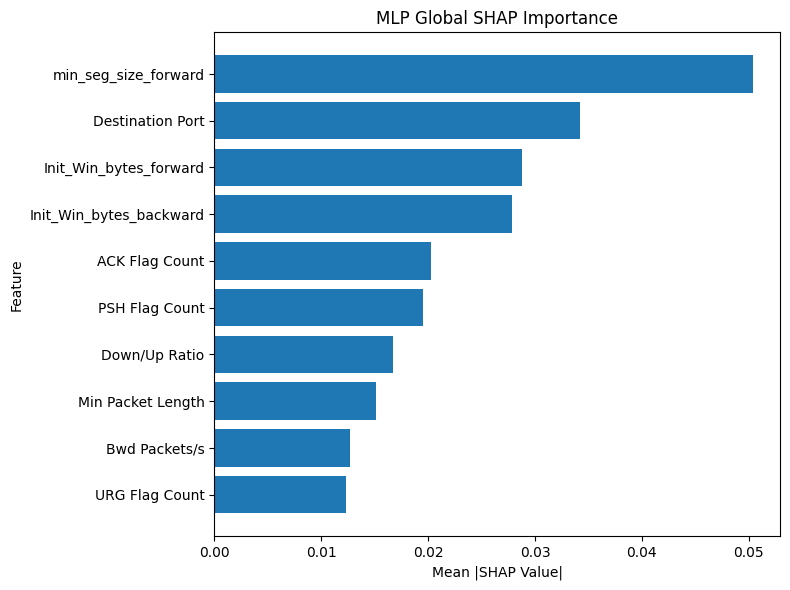

In [56]:
# MLP Global SHAP Plot


top10_mlp = mlp_shap_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10_mlp["Feature"][::-1],
    top10_mlp["Mean_SHAP"][::-1]
)

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.title("MLP Global SHAP Importance")

plt.tight_layout()

plt.show()

In [57]:
## 7.4 Global Explainability Comparison

In [58]:
# Top 10 Features Comparison


comparison_df = pd.DataFrame({
    "Random Forest": rf_shap_importance["Feature"].head(10).values,
    "XGBoost": xgb_shap_importance["Feature"].head(10).values,
    "MLP": mlp_shap_importance["Feature"].head(10).values
})

comparison_df

,Random Forest,XGBoost,MLP
0,Destination Port,Destination Port,min_seg_size_forward
1,Bwd Packet Length Min,Init_Win_bytes_backward,Destination Port
2,Init_Win_bytes_backward,Bwd Packets/s,Init_Win_bytes_forward
3,Average Packet Size,Init_Win_bytes_forward,Init_Win_bytes_backward
4,Init_Win_bytes_forward,Packet Length Mean,ACK Flag Count
5,Flow Packets/s,min_seg_size_forward,PSH Flag Count
6,Total Length of Fwd Packets,Fwd IAT Min,Down/Up Ratio
7,Bwd Packets/s,PSH Flag Count,Min Packet Length
8,min_seg_size_forward,Flow Bytes/s,Bwd Packets/s
9,Flow IAT Mean,Flow IAT Min,URG Flag Count


In [59]:
# Common Features Across Models


rf_top10 = set(
    rf_shap_importance["Feature"].head(10)
)

xgb_top10 = set(
    xgb_shap_importance["Feature"].head(10)
)

mlp_top10 = set(
    mlp_shap_importance["Feature"].head(10)
)

common_features = (
    rf_top10
    .intersection(xgb_top10)
    .intersection(mlp_top10)
)

print("Common Features Across Models:\n")

for feature in sorted(common_features):
    print(feature)

Common Features Across Models:

Bwd Packets/s
Destination Port
Init_Win_bytes_backward
Init_Win_bytes_forward
min_seg_size_forward


In [60]:
# Number of Common Features

print(
    "Number of Common Features:",
    len(common_features)
)

Number of Common Features: 5


In [61]:
# Global SHAP Summary


summary_df = pd.DataFrame({
    "Feature": list(common_features)
})

summary_df

,Feature
0,Destination Port
1,Bwd Packets/s
2,Init_Win_bytes_backward
3,min_seg_size_forward
4,Init_Win_bytes_forward


In [62]:
#Best Model = XGBoost

In [63]:
# 8. Local Explainability Analysis Using SHAP

#Section ini menganalisis prediksi individual menggunakan SHAP Local Explanation untuk memahami mengapa model mengklasifikasikan instance serangan tertentu.

In [64]:
## 8.1 DoS

In [65]:
# Correctly Classified DoS Sample


dos_idx = np.where(
    (y_test == 3) &
    (y_pred_xgb == 3)
)[0]

sample_dos = dos_idx[0]

print("Selected DoS Sample:", sample_dos)

Selected DoS Sample: 6


In [66]:
# DoS Prediction Probability


proba = xgb_model.predict_proba(
    X_test.iloc[[sample_dos]]
)

print("True Label      :", y_test[sample_dos])
print("Predicted Label :", y_pred_xgb[sample_dos])

print("\nClass Probabilities:")

for i, p in enumerate(proba[0]):
    print(f"Class {i}: {p:.6f}")

True Label      : 3
Predicted Label : 3

Class Probabilities:
Class 0: 0.000020
Class 1: 0.000002
Class 2: 0.000010
Class 3: 0.999941
Class 4: 0.000003
Class 5: 0.000024


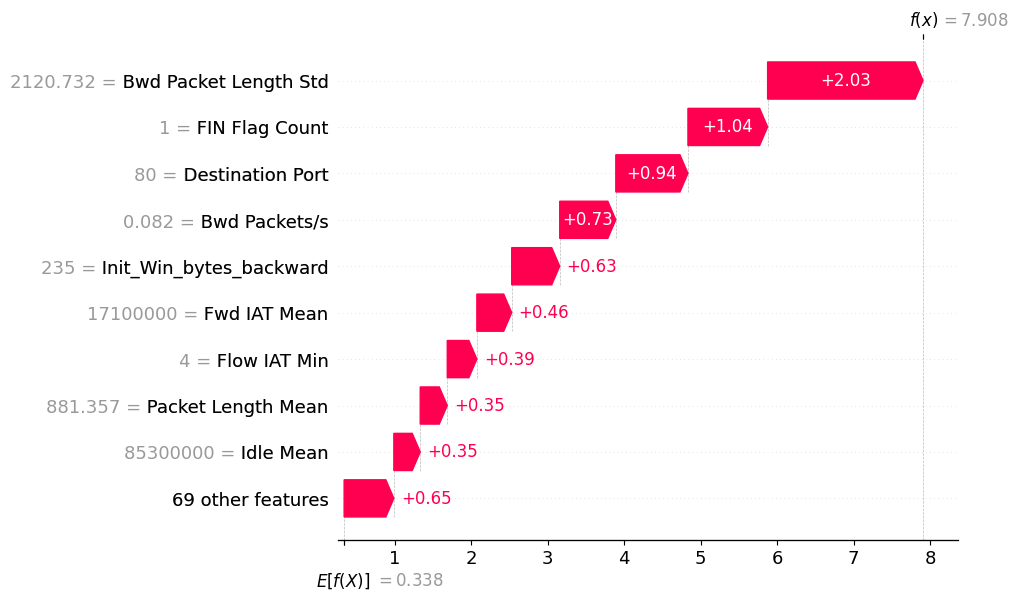

In [67]:
# DoS Local SHAP


shap.plots.waterfall(
    shap_values_xgb[
        sample_dos,
        :,
        3
    ],
    max_display=10
)

In [68]:
## 8.2 PortScan Sample

In [69]:
# Correctly Classified PortScan Sample


portscan_idx = np.where(
    (y_test == 4) &
    (y_pred_xgb == 4)
)[0]

sample_portscan = portscan_idx[0]

print("Selected PortScan Sample:", sample_portscan)

Selected PortScan Sample: 3


In [70]:
# PortScan Prediction Probability


proba = xgb_model.predict_proba(
    X_test.iloc[[sample_portscan]]
)

print("True Label      :", y_test[sample_portscan])
print("Predicted Label :", y_pred_xgb[sample_portscan])

print("\nClass Probabilities:")

for i, p in enumerate(proba[0]):
    print(f"Class {i}: {p:.6f}")

True Label      : 4
Predicted Label : 4

Class Probabilities:
Class 0: 0.000004
Class 1: 0.000023
Class 2: 0.000002
Class 3: 0.000002
Class 4: 0.999967
Class 5: 0.000003


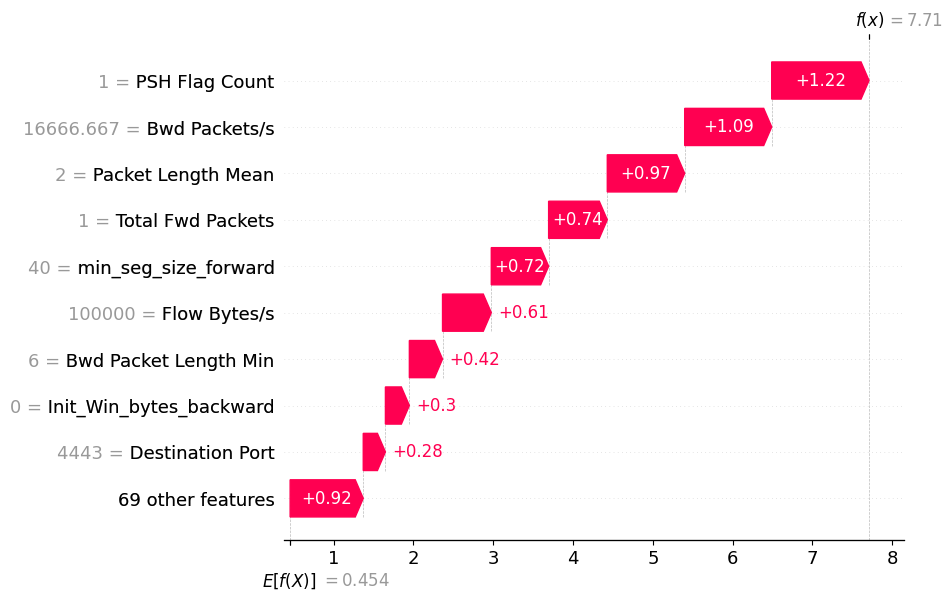

In [71]:
# PortScan Local SHAP


shap.plots.waterfall(
    shap_values_xgb[
        sample_portscan,
        :,
        4
    ],
    max_display=10
)

In [72]:
## 8.3 Bot Sample

In [73]:
# Correctly Classified Bot Sample


bot_idx = np.where(
    (y_test == 1) &
    (y_pred_xgb == 1)
)[0]

sample_bot = bot_idx[0]

print("Selected Bot Sample:", sample_bot)

Selected Bot Sample: 5


In [74]:
# Bot Prediction Probability


proba = xgb_model.predict_proba(
    X_test.iloc[[sample_bot]]
)

print("True Label      :", y_test[sample_bot])
print("Predicted Label :", y_pred_xgb[sample_bot])

print("\nClass Probabilities:")

for i, p in enumerate(proba[0]):
    print(f"Class {i}: {p:.6f}")

True Label      : 1
Predicted Label : 1

Class Probabilities:
Class 0: 0.000095
Class 1: 0.999874
Class 2: 0.000011
Class 3: 0.000006
Class 4: 0.000008
Class 5: 0.000006


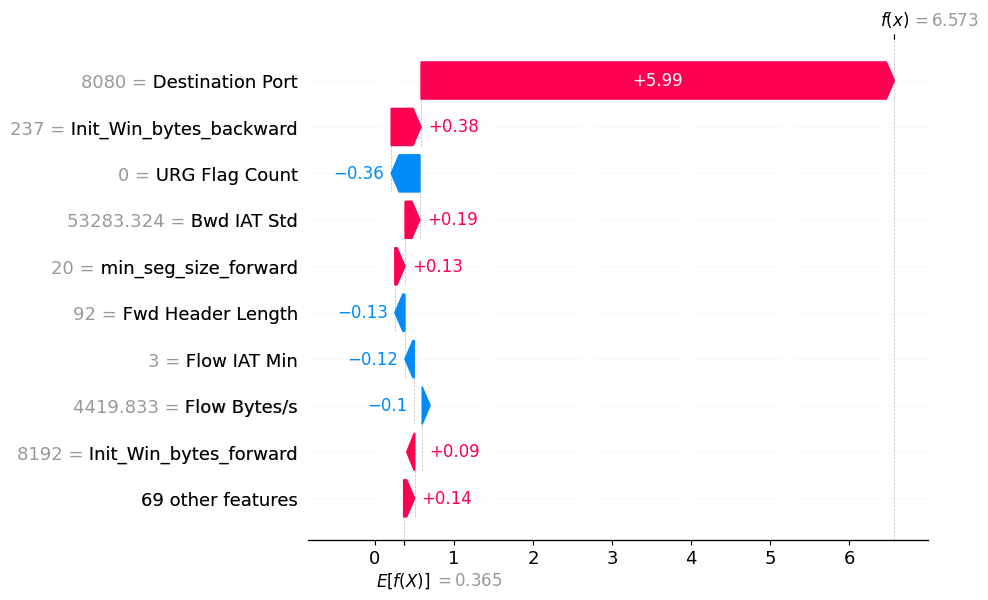

In [75]:
# Bot Local SHAP


shap.plots.waterfall(
    shap_values_xgb[
        sample_bot,
        :,
        1
    ],
    max_display=10
)

In [76]:
# 9. Local Explainability using LIME

#Section ini menganalisis prediksi individual menggunakan LIME untuk menjelaskan keputusan dari model terbaik (XGBoost). Penjelasan lokal disajikan untuk tiga kelas serangan representatif: DoS, PortScan, dan Bot.

In [77]:
## 9.1 LIME Explainer

In [78]:
# LIME Explainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[
        "Benign",
        "Bot",
        "BruteForce",
        "DoS",
        "PortScan",
        "WebAttack"
    ],
    mode="classification"
)

print("LIME Explainer Created")

LIME Explainer Created


In [79]:
# LIME Explanation for DoS Sample

lime_exp_dos = lime_explainer.explain_instance(
    X_test.iloc[sample_dos].values,
    xgb_model.predict_proba,
    labels=[3],
    num_features=10
)

print("LIME DoS Explanation Created")

LIME DoS Explanation Created


In [80]:
# LIME Feature Importance


lime_features = pd.DataFrame(
    lime_exp_dos.as_list(label=3),
    columns=[
        "Feature",
        "Weight"
    ]
)

lime_features

,Feature,Weight
0,FIN Flag Count > 0.00,0.189135
1,Bwd Packet Length Std > 23.13,0.143347
2,Destination Port <= 80.00,0.076066
3,Packet Length Mean > 56.62,0.026828
4,Bwd IAT Min > 4.00,-0.022439
5,Fwd Packet Length Max > 46.00,-0.019928
6,min_seg_size_forward <= 20.00,-0.018313
7,Idle Min > 0.00,0.014774
8,Bwd Packets/s <= 0.18,0.014548
9,Active Max > 0.00,-0.013320


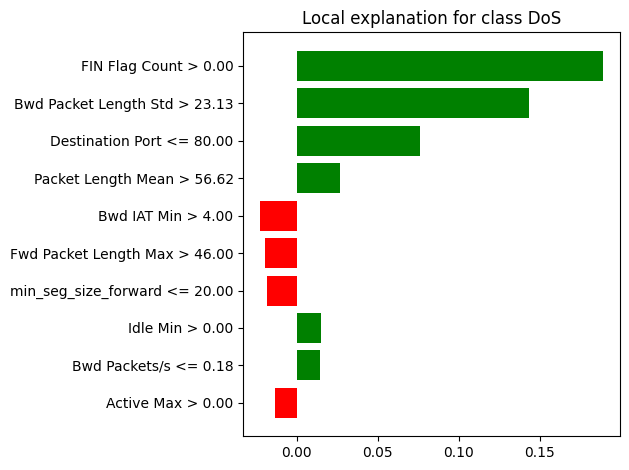

In [81]:
# DoS LIME Visualization


fig = lime_exp_dos.as_pyplot_figure(label=3)

plt.tight_layout()

plt.show()

In [82]:
## 9.2 PortScan LIME

In [83]:
# PortScan LIME Explanation


lime_exp_portscan = lime_explainer.explain_instance(
    X_test.iloc[sample_portscan].values,
    xgb_model.predict_proba,
    labels=[4],
    num_features=10
)

print("PortScan LIME Explanation Created")

PortScan LIME Explanation Created


In [84]:
# PortScan LIME Feature Importance


lime_portscan = pd.DataFrame(
    lime_exp_portscan.as_list(label=4),
    columns=[
        "Feature",
        "Weight"
    ]
)

lime_portscan

,Feature,Weight
0,Packet Length Mean <= 2.00,0.113845
1,0.00 < PSH Flag Count <= 1.00,0.107944
2,Bwd Packets/s > 12987.01,0.087779
3,Total Fwd Packets <= 1.00,0.087374
4,Flow IAT Max <= 61.00,0.048572
5,min_seg_size_forward > 32.00,0.042353
6,0.00 < Bwd Packet Length Min <= 6.00,0.038981
7,44.00 < Flow IAT Min <= 94.00,0.037926
8,ACK Flag Count <= 0.00,0.033175
9,80.00 < Destination Port <= 5087.00,0.031358


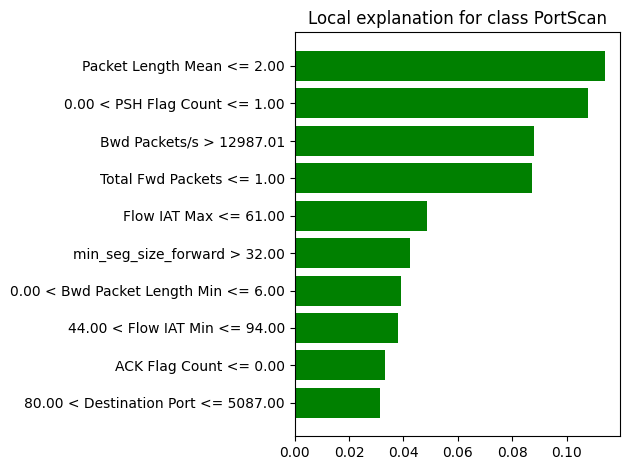

In [85]:
# PortScan LIME Visualization


fig = lime_exp_portscan.as_pyplot_figure(label=4)

plt.tight_layout()

plt.show()

In [86]:
## 9.3 Bot LIME

In [87]:
# Bot LIME Explanation


lime_exp_bot = lime_explainer.explain_instance(
    X_test.iloc[sample_bot].values,
    xgb_model.predict_proba,
    labels=[1],
    num_features=10
)

print("Bot LIME Explanation Created")

Bot LIME Explanation Created


In [88]:
# Bot LIME Feature Importance


lime_bot = pd.DataFrame(
    lime_exp_bot.as_list(label=1),
    columns=[
        "Feature",
        "Weight"
    ]
)

lime_bot

,Feature,Weight
0,229.00 < Init_Win_bytes_backward <= 256.00,0.022456
1,Destination Port > 5087.00,0.014456
2,URG Flag Count <= 0.00,-0.013823
3,1.00 < Total Backward Packets <= 3.00,0.012013
4,Active Std <= 0.00,0.011669
5,251.00 < Init_Win_bytes_forward <= 8192.00,0.010948
6,Bwd Packet Length Min <= 0.00,0.010049
7,3.00 < Subflow Fwd Packets <= 4.00,0.009667
8,0.00 < Bwd IAT Total <= 147450.75,0.009304
9,Packet Length Std > 75.29,0.009215


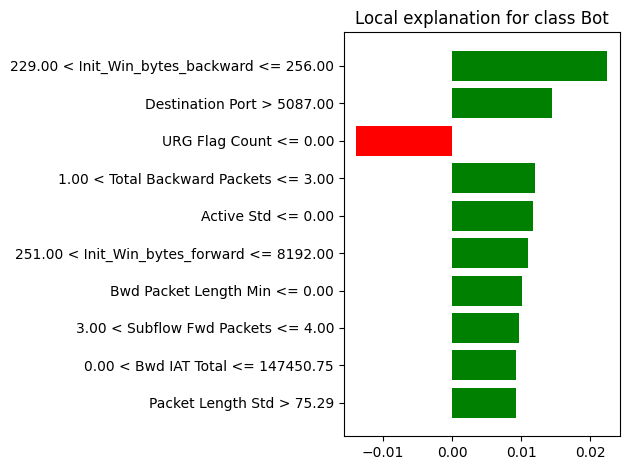

In [89]:
# Bot LIME Visualization


fig = lime_exp_bot.as_pyplot_figure(label=1)

plt.tight_layout()

plt.show()